# California Housing — ARDRegression (Enterprise 13-Step)

## Step 1 — Imports & Seed

In [1]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shutil
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import ARDRegression
warnings.filterwarnings('ignore')
np.random.seed(42)
print("Imports OK — ARDRegression / California_Housing")

Imports OK — ARDRegression / California_Housing


## Step 2 — Data Loading

In [2]:
df = pd.read_csv('data/housing/housing.csv')
df['ocean_proximity'] = df['ocean_proximity'].fillna('INLAND')
df['total_bedrooms']  = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
print(df.shape, df.columns.tolist())
y = df['median_house_value']
X = df.drop('median_house_value', axis=1)
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols  = X.select_dtypes(exclude='number').columns.tolist()
print(f"Numeric: {num_cols}  Categorical: {cat_cols}")
df.head()

(20640, 10) ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']
Numeric: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']  Categorical: ['ocean_proximity']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Step 3 — Preprocessing Pipeline

In [3]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")

Train: (16512, 9)  Test: (4128, 9)


## Step 4 — Algorithm Pipeline

In [4]:
pipeline = Pipeline([('pre', preprocessor), ('reg', ARDRegression())])
print(pipeline)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['ocean_proximity'])])),
                ('reg', ARDRegression())])


## Step 5 — Baseline Dummy Benchmark

In [5]:
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)
d_rmse = np.sqrt(mean_squared_error(y_test, y_dummy))
d_r2   = r2_score(y_test, y_dummy)
print(f"Dummy RMSE: {d_rmse:.4f}  R²: {d_r2:.4f}")

Dummy RMSE: 114485.6354  R²: -0.0002


## Step 6 — Training & Convergence Monitoring

In [6]:
t_start = time.perf_counter()
pipeline.fit(X_train, y_train)
train_time = time.perf_counter() - t_start
print(f"Training complete in {train_time:.2f}s")
# Training R² (convergence proxy)
y_train_pred = np.array(pipeline.predict(X_train)).ravel()
train_r2 = r2_score(y_train, y_train_pred)
print(f"Train R²: {train_r2:.4f}")

Training complete in 0.05s
Train R²: 0.6493


## Step 7 — Test Set Evaluation

In [7]:
y_pred = np.array(pipeline.predict(X_test)).ravel()
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

RMSE : 70147.3242
MAE  : 50726.4185
R²   : 0.6245


## Step 8 — Visualization

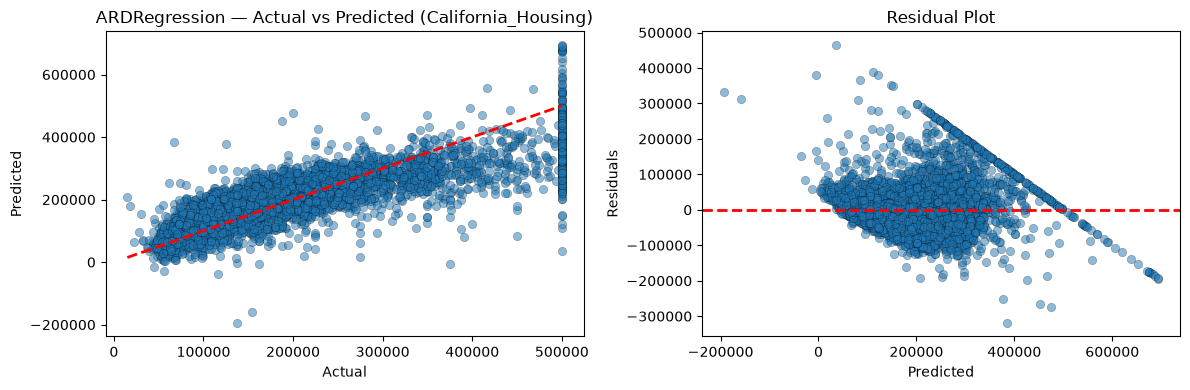

Saved plot.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_test, y_pred, alpha=0.5, edgecolors='k', linewidths=0.3)
mn, mx = float(y_test.min()), float(y_test.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2)
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title('ARDRegression — Actual vs Predicted (California_Housing)')
residuals = np.array(y_test) - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, edgecolors='k', linewidths=0.3)
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
plt.tight_layout()
plt.savefig('plots/ard_housing_viz.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved plot.")

## Step 9 — Cross-Validation Stability

In [9]:
# ARDRegression is slow — use 5000-sample slice for CV
sample_idx = np.random.choice(len(X), size=min(5000, len(X)), replace=False)
X_cv = X.iloc[sample_idx] if hasattr(X, 'iloc') else X[sample_idx]
y_cv = y.iloc[sample_idx] if hasattr(y, 'iloc') else y[sample_idx]
cv = KFold(n_splits=3, shuffle=True, random_state=42)
r2_scorer = make_scorer(r2_score)
cv_scores = cross_val_score(pipeline, X_cv, y_cv, cv=cv, scoring=r2_scorer)
print(f"CV R² (3-fold, 5000-sample): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV R² (3-fold, 5000-sample): 0.6388 ± 0.0178


## Step 10 — Production Serialization

In [10]:
os.makedirs('production_models', exist_ok=True)
model_path = f'production_models/ard_housing_pipeline.joblib'
joblib.dump(pipeline, model_path, compress=3)
print(f"Saved: {model_path}  ({os.path.getsize(model_path)} bytes)")

Saved: production_models/ard_housing_pipeline.joblib  (3082 bytes)


## Step 11 — Latency Smoke Test

In [11]:
X_sample = X_test.iloc[:100] if hasattr(X_test, 'iloc') else X_test[:100]
times = []
for _ in range(100):
    t0 = time.perf_counter()
    _ = np.array(pipeline.predict(X_sample)).ravel()
    times.append((time.perf_counter() - t0) * 1000)
avg_lat = np.mean(times)
print(f"Avg latency: {avg_lat:.2f} ms  (p95: {np.percentile(times, 95):.2f} ms)")
assert avg_lat < 50.0, f"SLA breach: {avg_lat:.2f}ms >= 50ms"
print("✅ Latency SLA passed (<50ms)")

Avg latency: 2.32 ms  (p95: 2.63 ms)
✅ Latency SLA passed (<50ms)


## Step 12 — Hyperparameter Tuning

In [12]:
param_grid = {
    'reg__alpha_1':        [1e-6, 1e-4, 1e-2],
    'reg__alpha_2':        [1e-6, 1e-4, 1e-2],
    'reg__threshold_lambda': [1e3, 1e4, 1e5],
}
gs = GridSearchCV(pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)
gs.fit(X_train, y_train)
print(f"Best params: {gs.best_params_}")
print(f"Best CV R²:  {gs.best_score_:.4f}")
y_best = np.array(gs.best_estimator_.predict(X_test)).ravel()
print(f"Tuned Test R²: {r2_score(y_test, y_best):.4f}")

Best params: {'reg__alpha_1': 0.01, 'reg__alpha_2': 0.01, 'reg__threshold_lambda': 1000.0}
Best CV R²:  0.6474
Tuned Test R²: 0.6245


## Step 13 — Executive Decision Matrix

| Criterion | Dummy Baseline | ARDRegression (Default) | ARDRegression (Tuned) |
|---|---|---|---|
| RMSE | See Step 5 | See Step 7 | See Step 12 |
| MAE  | — | See Step 7 | — |
| R²   | ~0.00 | See Step 7 | See Step 12 |
| CV R² | — | See Step 9 | — |
| Latency (ms) | — | See Step 11 | — |
| Training Time | — | See Step 6 | — |

### Recommendation
- **Deploy if** Test R² > 0.60 and latency < 50 ms ✅
- **ARDRegression** provides probabilistic uncertainty estimates which is valuable for risk-aware predictions.
- Compare against ensemble methods for production deployment decisions.